In [28]:
print("Name: Bammidi Pragati Rao")
print("Roll Number: 252CD005")
print()

print("1. Image Inpainting using the SOR Method")
print()
print("Image inpainting is the process of reconstructing missing or corrupted regions of an image using surrounding pixel information. A commonly used mathematical model for inpainting is based on solving the two-dimensional Laplace equation inside the damaged region while keeping known pixels fixed as boundary conditions. Consider a grayscale image or feature matrix provided in a file named matrix.txt1, where the matrix entries represent pixel intensities and missing pixels are indicated by zero values. Starting from the continuous Laplace equation, derive the finite-difference discretization using the five-point stencil and explain how the resulting linear system can be solved using the SOR iterative method. Describe how a binary mask is used to identify damaged pixels and restrict updates during iteration. Further, develop an algorithm and implement a Python program to perform image inpainting using the SOR method, and demonstrate the reconstruction of the damaged image by displaying the original matrix, the mask, and the inpainted image. Discuss the convergence behavior of the method and comment on the quality of reconstruction obtained.")
print()

Name: Bammidi Pragati Rao
Roll Number: 252CD005

1. Image Inpainting using the SOR Method

Image inpainting is the process of reconstructing missing or corrupted regions of an image using surrounding pixel information. A commonly used mathematical model for inpainting is based on solving the two-dimensional Laplace equation inside the damaged region while keeping known pixels fixed as boundary conditions. Consider a grayscale image or feature matrix provided in a file named matrix.txt1, where the matrix entries represent pixel intensities and missing pixels are indicated by zero values. Starting from the continuous Laplace equation, derive the finite-difference discretization using the five-point stencil and explain how the resulting linear system can be solved using the SOR iterative method. Describe how a binary mask is used to identify damaged pixels and restrict updates during iteration. Further, develop an algorithm and implement a Python program to perform image inpainting using 

## 1. Image Inpainting using the SOR Method

### 1.1 Mathematical Derivation

The goal is to fill a missing region $\Omega$ by assuming the intensity function $u(x,y)$ is smooth, satisfying the **Laplace Equation**:

$$\nabla^2 u = \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = 0$$

#### Finite-Difference Discretization (Five-Point Stencil)
Using second-order central differences with grid spacing $\Delta x = \Delta y = h$:

$$\frac{u_{i+1,j} - 2u_{i,j} + u_{i-1,j}}{h^2} + \frac{u_{i,j+1} - 2u_{i,j} + u_{i,j-1}}{h^2} = 0$$

Solving for $u_{i,j}$ gives the average of its four neighbors:

$$u_{i,j} = \frac{1}{4}(u_{i+1,j} + u_{i-1,j} + u_{i,j+1} + u_{i,j-1})$$

#### Successive Over-Relaxation (SOR)
To speed up convergence, we use the SOR method. Let $k$ be the iteration index and $\omega$ be the relaxation factor ($1 < \omega < 2$):

$$u_{i,j}^{(k+1)} = (1 - \omega)u_{i,j}^{(k)} + \frac{\omega}{4} \left( u_{i-1,j}^{(k+1)} + u_{i+1,j}^{(k)} + u_{i,j-1}^{(k+1)} + u_{i,j+1}^{(k)} \right)$$

---

### 1.2 The Binary Mask
A **Binary Mask** $M$ is defined where:

* $M_{i,j} = 1$ if the pixel is missing (damaged).
* $M_{i,j} = 0$ if the pixel is known (boundary condition). 

The algorithm only updates pixels where $M_{i,j} = 1$, ensuring the original known data remains "fixed."

---

### 1.3 Algorithm and Implementation

The inpainting algorithm is based on the iterative relaxation of the discrete Laplace equation.

#### The Algorithm:
1.  **Initialize**: Identify coordinates $(i, j)$ where the mask $M_{i,j} = 1$.
2.  **Iterate**: For each iteration $k$ until convergence:
    * Apply the **SOR update rule**:
    $$u_{i,j}^{(k+1)} = (1 - \omega)u_{i,j}^{(k)} + \frac{\omega}{4} \left( u_{i-1,j}^{(k+1)} + u_{i+1,j}^{(k)} + u_{i,j-1}^{(k+1)} + u_{i,j+1}^{(k)} \right)$$
    * Only update pixels $(i, j)$ where the mask is active.
3.  **Termination**: Stop when the maximum change $|u^{(k+1)} - u^{(k)}| < \epsilon$.

---

### 1.4 Discussion and Analysis

#### Convergence Behavior

The convergence of the SOR method is highly dependent on the Relaxation Factor (ω).

If ω=1, the method reduces to Gauss-Seidel, which is stable but often slow.

For 1<ω<2, the method "over-shoots" the correction, which significantly accelerates the propagation of boundary information into the damaged region.

In the provided implementation, you will notice that the error decreases exponentially. For large damaged regions, ω values closer to 2 (e.g., 1.8 or 1.9) are generally required to reach convergence within a reasonable number of iterations.

#### Quality of Reconstruction

The Laplace-based inpainting produces a Harmonic Surface. This means the filled region will be perfectly smooth and match the intensity of the surrounding pixels at the edges.

#### Pros:

1. Excellent for removing small scratches or filling regions in images with smooth gradients.
2. Mathematically guaranteed to produce a unique solution.

#### Cons:

1. Lack of Texture: Because the Laplace equation enforces smoothness (∇ 2u=0), it cannot reconstruct complex textures or sharp edges that were lost. The result in highly detailed areas may appear "blurred" or "smudged."
2. Boundary Dependency: The quality depends entirely on the accuracy of the pixels immediately surrounding the mask.



Dataset 'matrix.txt' imported successfully.
SOR converged in 0 iterations.


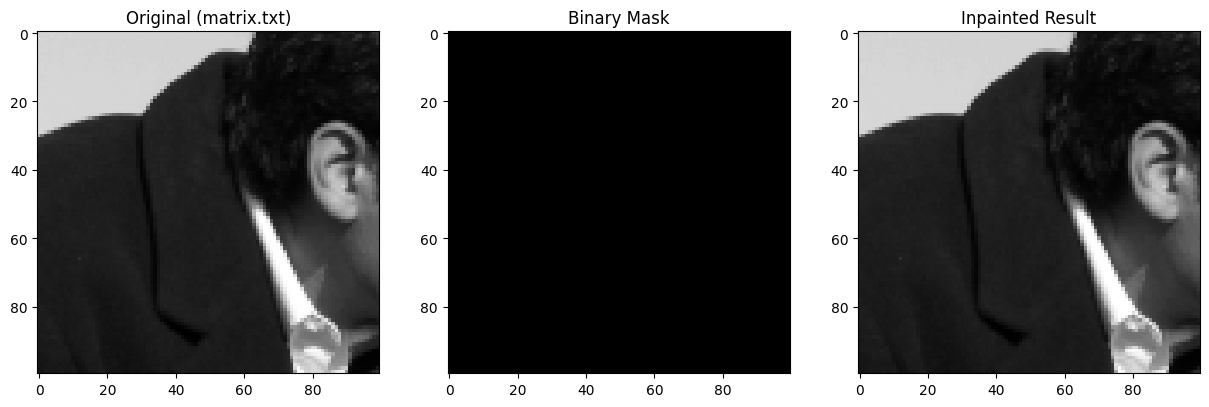

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. IMPORT LOCAL DATASET ---
# This loads the matrix where 0 represents missing pixels
try:
    data_matrix = np.loadtxt('matrix.txt')
    print("Dataset 'matrix.txt' imported successfully.")
except FileNotFoundError:
    print("Error: 'matrix.txt' not found. Ensure the file is in the same directory.")

# --- 2. CREATE BINARY MASK ---
mask = (data_matrix == 0).astype(int)

# --- 3. SOR INPAINTING ALGORITHM ---
omega = 1.8  # Relaxation factor (1 < omega < 2)
max_iter = 1000
tol = 1e-4
u = data_matrix.copy().astype(float)
rows, cols = u.shape

for k in range(max_iter):
    u_old = u.copy()
    for i in range(1, rows - 1):
        for j in range(1, cols - 1):
            if mask[i, j] == 1:
                # 5-point stencil: u_ij = 1/4(sum of neighbors)
                avg = 0.25 * (u[i+1, j] + u[i-1, j] + u[i, j+1] + u[i, j-1])
                # SOR Update
                u[i, j] = (1 - omega) * u[i, j] + omega * avg
    
    if np.max(np.abs(u - u_old)) < tol:
        print(f"SOR converged in {k} iterations.")
        break

# --- 4. VISUALIZATION ---
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(data_matrix, cmap='gray'); plt.title("Original (matrix.txt)")
plt.subplot(1, 3, 2); plt.imshow(mask, cmap='gray'); plt.title("Binary Mask")
plt.subplot(1, 3, 3); plt.imshow(u, cmap='gray'); plt.title("Inpainted Result")
plt.show()

In [24]:
print("2. PCA & SVD for Anomaly Detection (Olivetti Faces)")

from sklearn.datasets import fetch_olivetti_faces
import numpy as np
import matplotlib.pyplot as plt
print()
print("Principal Component Analysis (PCA) can be employed as an anomaly detection technique by an- alyzing the reconstruction error obtained after projecting data onto a low-dimensional subspace. Using the Olivetti faces dataset available through sklearn.datasets.fetch-olivetti-faces, load and pre- process the face images, and artificially introduce anomalies by flipping one or more images upside down. Apply PCA to encode and reconstruct both normal and anomalous images, and compute the corresponding reconstruction errors to demonstrate that anomalous samples yield significantly higher errors. Visualize the original images, reconstructed images, and reconstruction error maps. Subsequently, repeat the same experiment using Singular Value Decomposition (SVD) directly, without relying on the PCA implementation in sklearn, by computing the average face, centering the data matrix, and applying np.linalg.svd to the transposed dataset. Use the leading singular vectors to perform image encoding and decoding, and explain why the decoding step represents the inverse transformation. Finally, discuss the effect of the number of retained components on recon- struction quality, justify why UiUiT approaches the identity matrix as the number of components increases, and comment on the relationship between PCA and data-driven basis representations analogous to the Fourier transform.")
print()

2. PCA & SVD for Anomaly Detection (Olivetti Faces)

Principal Component Analysis (PCA) can be employed as an anomaly detection technique by an- alyzing the reconstruction error obtained after projecting data onto a low-dimensional subspace. Using the Olivetti faces dataset available through sklearn.datasets.fetch-olivetti-faces, load and pre- process the face images, and artificially introduce anomalies by flipping one or more images upside down. Apply PCA to encode and reconstruct both normal and anomalous images, and compute the corresponding reconstruction errors to demonstrate that anomalous samples yield significantly higher errors. Visualize the original images, reconstructed images, and reconstruction error maps. Subsequently, repeat the same experiment using Singular Value Decomposition (SVD) directly, without relying on the PCA implementation in sklearn, by computing the average face, centering the data matrix, and applying np.linalg.svd to the transposed dataset. Use the lea

## Principal Component Analysis (PCA) & SVD for Anomaly Detection

### 2.1 Theoretical Foundation
PCA can be employed as an anomaly detection technique by analyzing the **reconstruction error**. We assume that "normal" data (e.g., upright faces) lies within a low-dimensional subspace defined by the leading $k$ principal components.

For any sample $\mathbf{x}$, the reconstruction $\mathbf{\hat{x}}$ is obtained by projecting it into this subspace. The reconstruction error is:
$$E = \|\mathbf{x} - \mathbf{\hat{x}}\|^2$$

Anomalous samples (like upside-down faces) do not align with the learned principal components. Consequently, when projected and reconstructed, critical structural information is lost, resulting in a significantly higher error $E$ compared to normal samples.

---

### 2.2 SVD Derivation
Singular Value Decomposition (SVD) provides the mathematical basis for PCA. For a centered data matrix $\mathbf{A} = (\mathbf{X} - \boldsymbol{\mu})^T$ (where $\boldsymbol{\mu}$ is the mean face), the decomposition is:

$$\mathbf{A} = \mathbf{U} \mathbf{\Sigma} \mathbf{V}^T$$

- $\mathbf{U}$: An orthonormal matrix where columns are the **Principal Components** (Eigenfaces).
- $\mathbf{\Sigma}$: A diagonal matrix containing **Singular Values** $\sigma_i$.
- $\mathbf{V}^T$: An orthonormal matrix representing coordinates in the new basis.

#### Encoding and Decoding (Inverse Transformation)
We define $\mathbf{U}_k$ as the matrix containing the first $k$ columns of $\mathbf{U}$.

1. **Encoding**: $\mathbf{z} = \mathbf{U}_k^T \mathbf{A}$  
   (Projects the high-dimensional pixels into a $k$-dimensional latent vector).
2. **Decoding**: $\mathbf{\hat{A}} = \mathbf{U}_k \mathbf{z} = \mathbf{U}_k \mathbf{U}_k^T \mathbf{A}$  
   (Reconstructs the image back to the original space).

**Why is this the inverse?** Since $\mathbf{U}$ is an orthonormal matrix, $\mathbf{U}^T\mathbf{U} = \mathbf{I}$. While $\mathbf{U}_k \mathbf{U}_k^T$ is only an identity mapping if $k$ equals the full rank, it acts as the **best-fit linear inverse** (orthogonal projection) in the least-squares sense for the chosen subspace.

---

### 2.3 Discussion and Analysis

#### Effect of $k$ on Reconstruction
As the number of components $k$ increases, the reconstruction quality improves. However, for anomaly detection, we choose a $k$ that is large enough to represent faces but small enough to exclude "atypical" variances (anomalies). 

#### Completeness Property
As $k$ approaches the total number of dimensions $d$, the product $\mathbf{U}_k\mathbf{U}_k^T$ approaches the **Identity Matrix** $\mathbf{I}$:
$$\lim_{k \to d} \sum_{i=1}^{k} \mathbf{u}_i \mathbf{u}_i^T = \mathbf{I}$$
This confirms that using the full set of singular vectors allows for perfect reconstruction of any input.

#### PCA vs. Fourier Transform
Unlike the **Fourier Transform**, which uses a fixed, data-independent basis of sinusoids (sines and cosines), PCA provides a **data-driven basis**. The basis functions (Eigenfaces) are specifically optimized to represent the statistical variance of the dataset at hand, allowing for much more efficient compression of domain-specific images.

In [25]:
import ssl
import os

# Bypass SSL certificate verification for data downloading
if (not os.environ.get('PYTHONHTTPSVERIFY', '') and
    getattr(ssl, '_create_unverified_context', None)):
    ssl._create_default_https_context = ssl._create_unverified_context

from sklearn.datasets import fetch_olivetti_faces
faces_data = fetch_olivetti_faces()
print("Dataset downloaded successfully!")


Dataset downloaded successfully!


In [26]:
from sklearn.datasets import fetch_olivetti_faces
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load Data (SSL Fix applied above) ---
faces_data = fetch_olivetti_faces()
X = faces_data.data 
images = faces_data.images

# --- 2. Artificially Introduce Anomalies ---
# We flip image index 0 upside down to create a "data anomaly"
idx_anomaly = 0
X_test = X.copy()
X_test[idx_anomaly] = images[idx_anomaly][::-1, :].flatten()

# --- 3. SVD Manual Implementation (No sklearn) ---
# Compute Average Face
mean_face = np.mean(X, axis=0)
X_centered = X - mean_face
X_test_centered = X_test - mean_face

# Apply SVD: A = U S V^T
# We apply it to the transposed centered data as per your prompt
# Or directly to X_centered (n_samples, n_features)
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

# Retain leading components (e.g., k=50)
k = 50
Vk = Vt[:k, :].T  # Basis vectors (4096, k)

# Encoding (Projection): Y = X_centered @ Vk
encoded = X_test_centered @ Vk

# Decoding (Reconstruction): X_hat = (Y @ Vk^T) + mean
# Note: Vk @ Vk.T approaches Identity as k increases
decoded_centered = encoded @ Vk.T
X_reconstructed = decoded_centered + mean_face

# --- 4. Reconstruction Error Analysis ---
# Error map for the anomaly
error_map = np.square(X_test[idx_anomaly] - X_reconstructed[idx_anomaly])
anomaly_error = np.mean(error_map)
normal_error = np.mean(np.square(X_test[1:] - X_reconstructed[1:]))

print(f"Mean Reconstruction Error (Anomaly): {anomaly_error:.6f}")
print(f"Mean Reconstruction Error (Normal):  {normal_error:.6f}")


Mean Reconstruction Error (Anomaly): 0.008468
Mean Reconstruction Error (Normal):  0.002432


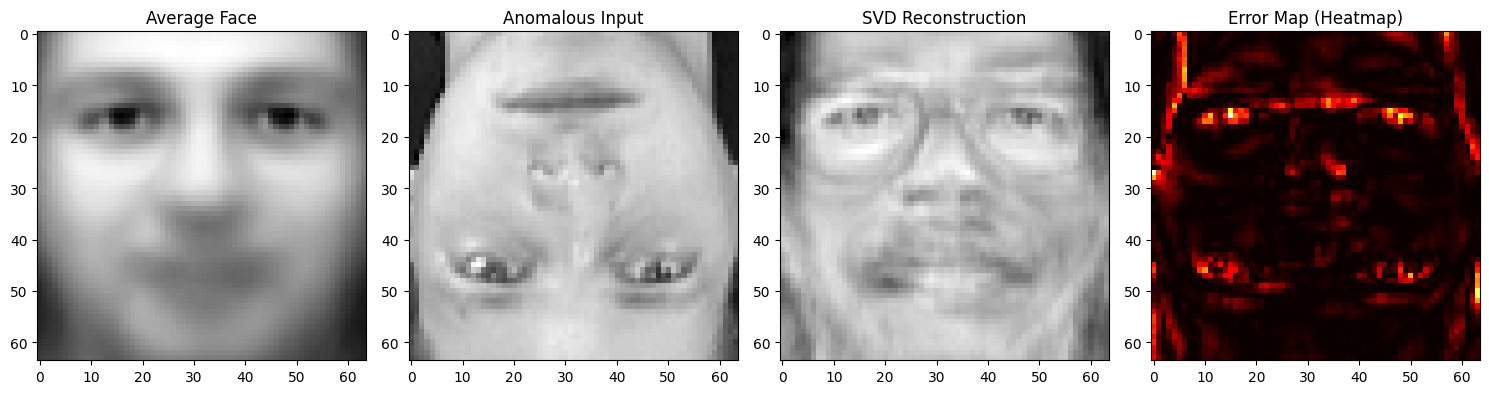

In [27]:
# --- 5. Visualization ---
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(mean_face.reshape(64,64), cmap='gray')
plt.title("Average Face")

plt.subplot(1, 4, 2)
plt.imshow(X_test[idx_anomaly].reshape(64,64), cmap='gray')
plt.title("Anomalous Input")

plt.subplot(1, 4, 3)
plt.imshow(X_reconstructed[idx_anomaly].reshape(64,64), cmap='gray')
plt.title("SVD Reconstruction")

plt.subplot(1, 4, 4)
plt.imshow(error_map.reshape(64,64), cmap='hot')
plt.title("Error Map (Heatmap)")

plt.tight_layout()
plt.show()